# Anomaly Detection

## Problem Formulation

In this project, we focus on **anomaly detection in imbalanced datasets**, with a real-world business scenario: **detecting fraudulent transactions** from financial data.

### Business Context
In many industries, such as banking and e-commerce, fraudulent transactions are rare but extremely costly. The vast majority of transactions are legitimate, and only a small fraction—often less than 1%—are fraudulent. However, missing even one fraudulent transaction can result in significant financial loss, while falsely flagging legitimate transactions causes unnecessary customer friction and wasted investigation efforts.

### Key Challenges
- **Imbalanced data**: The dataset is highly skewed toward legitimate transactions. This makes standard machine learning models (which focus on overall accuracy) ineffective, as they may simply predict the majority class.
- **Trade-off between precision and recall**: High recall (catching as many frauds as possible) often comes at the cost of lower precision (more false alarms). Balancing this trade-off is crucial for practical applications.
- **Business impact**: Each fraudulent transaction has a cost, and each false alarm has a cost. Our models should balance these costs to deliver practical value.

### Objectives
1. Develop models that can **effectively detect fraud** in highly imbalanced data.
2. Evaluate models using metrics that focus on the minority (fraudulent) class: **precision, recall, F1-score, and PR AUC**.
3. **Visualize and interpret** results to guide business decisions (e.g., what threshold yields an acceptable balance of fraud detection vs false alerts).
4. Prepare a model that could be **deployed in a production environment**, including practical considerations like retraining, monitoring, and integration.

## Data collection and loading

Now that we’ve clearly defined the problem and our objectives, we will move on to data collection and loading. This step involves importing the necessary libraries, loading the dataset, and exploring its structure to ensure data integrity. Proper data loading and exploration set a solid foundation for the subsequent steps of the project.

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import precision_recall_curve, auc

In [2]:
# Load the dataset
file_path = 'sales.csv'
try:
    df = pd.read_csv(file_path, index_col=0)
    print("Data loaded successfully.")
except FileNotFoundError:
    print("File not found!")

Data loaded successfully.


In [3]:
# Display a small sample to get a sense of the data
print("\nSample rows from the dataset:")
display(df.head())

# Show basic dataset information
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Count occurrences of each class in 'Insp'
print("\nClass distribution in 'Insp':")
print(df['Insp'].value_counts())

# Also show as percentages
print("\nClass distribution in percentages:")
print((df['Insp'].value_counts(normalize=True) * 100).round(2))


Sample rows from the dataset:


,ID,Prod,Quant,Val,Insp
1,v1,p1,182.0,1665.0,unkn
2,v2,p1,3072.0,8780.0,unkn
3,v3,p1,20393.0,76990.0,unkn
4,v4,p1,112.0,1100.0,unkn
5,v3,p1,6164.0,20260.0,unkn



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 401146 entries, 1 to 411818
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      401146 non-null  object 
 1   Prod    401146 non-null  object 
 2   Quant   387304 non-null  float64
 3   Val     399964 non-null  float64
 4   Insp    401146 non-null  object 
dtypes: float64(2), object(3)
memory usage: 18.4+ MB

Missing Values per Column:
ID           0
Prod         0
Quant    13842
Val       1182
Insp         0
dtype: int64

Class distribution in 'Insp':
Insp
unkn     385414
ok        14462
fraud      1270
Name: count, dtype: int64

Class distribution in percentages:
Insp
unkn     96.08
ok        3.61
fraud     0.32
Name: proportion, dtype: float64


## Data preparation

In this step, we prepare our data for modeling by splitting it into training and test sets, and by performing essential data cleaning to ensure data quality and consistency. Proper data splitting ensures that our machine learning models are trained on one subset of data and evaluated on a separate, unseen subset, which helps prevent data leakage and provides a realistic estimate of model performance.

**Key Points:**
* **Drop missing values in Quant and Val:**
To ensure the integrity of the Uprice calculation and remove incomplete data, we first remove any rows where either Quant or Val is missing. This avoids division errors and ensures we only calculate meaningful unit prices.
* **Create the Uprice column:**
  The Uprice feature (calculated as Val / Quant) is a derived metric based solely on existing input features (Val and Quant). It's important to calculate it before data splitting to ensure consistency between training and testing sets. Adding it after splitting would risk information leakage or inconsistent data structures.
* **Split the data** into features (X) and target (y):
The target variable (Insp) contains the classification labels for our task (ok, fraud, unkn).
* **Use stratified sampling:**
By setting stratify=y, we ensure that the class distribution of Insp is preserved in both training and testing sets. This is crucial because the dataset is imbalanced, and we don't want the test set to have different proportions of classes.
* **Random State:**
Setting random_state=42 guarantees that the split is reproducible. This means anyone running the code with the same seed will obtain the same training and testing datasets.
* **Save the split datasets**
Cleaned and split datasets will be saved into CSV files, ready for later stages of the project.

In [4]:
# Drop rows with missing values in 'Quant' and 'Val'
df_clean = df.dropna(subset=['Quant', 'Val'])

# Create the Uprice column
df_clean['Uprice'] = df_clean['Val'] / df_clean['Quant']

# Separate features and target
X = df_clean.drop('Insp', axis=1)
y = df_clean['Insp']

# Split the data, stratified sampling to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

# Combine features and target back together for convenience
X_train = pd.concat([X_train, y_train], axis=1)
X_test = pd.concat([X_test, y_test], axis=1)

# Save the split datasets to CSV for later use
X_train.to_csv("train_clean.csv")
X_test.to_csv("test_clean.csv")

# Exploratory Data Analysis (EDA)

Now that we have prepared and cleaned our dataset, we move on to **exploratory data analysis (EDA)** to better understand the data's structure and identify potential issues before modeling. The following key points guide our analysis:

* **Perform EDA only on the training dataset** to avoid data leakage and ensure that no information from the test set biases the model.

* **Explore missing values**:
  * Count missing values for each column (Quant, Val, Uprice).
  * Identify rows where multiple fields are missing, which might indicate problematic records.
  * Check how many unique products have missing values and if certain products consistently lack data.

* **Remove missing values**:
  * Drop all rows where Quant, Val, or Uprice are missing. This ensures that the dataset used for analysis and modeling contains complete and consistent records.

* **Examine class distribution** in the target column Insp, which indicates labels (ok, fraud, unkn), and confirm class imbalance.

* **Investigate feature distributions** (Quant, Val) using summary statistics to detect skewness or outliers. Look for potential data quality issues or anomalies.

* **Analyze transaction patterns**:
  * Count the number of unique vendors and unique products.
  * Check how many transactions occur per vendor and per product. Identify skewness or products/vendors with disproportionately high or low numbers of transactions.

* **Prepare the dataset for modeling**:
  * Ensure that the cleaned and analyzed dataset is consistent and complete.
  * Save the clean dataset for future use in the modeling stage.

This structured EDA helps to identify imbalances, outliers, and data quality issues early, setting a solid foundation for robust modeling.

In [5]:
# Load the cleaned training data
X_train = pd.read_csv("train_clean.csv", index_col=0)

# Display first few rows
print("\nSample rows from the cleaned training set:")
display(X_train.head())

# Show general info about the data
print("\nDataset Info:")
X_train.info()

# Check for missing values
print("\nMissing Values per Column:")
print(X_train.isnull().sum())

# Count unique vendors
unique_vendors = X_train['ID'].nunique()
print(f"Total unique vendors: {unique_vendors}")

# Count unique products
unique_products = X_train['Prod'].nunique()
print(f"Total unique products: {unique_products}")

# Count transactions per vendor
transactions_per_vendor = X_train['ID'].value_counts()
print("\nTransactions per vendor (top 5):")
print(transactions_per_vendor.head())

# Count transactions per product
transactions_per_product = X_train['Prod'].value_counts()
print("\nTransactions per product (top 5):")
print(transactions_per_product.head())

# Summary statistics
print("\nSummary Statistics:")
display(X_train.describe())

# Distribution of 'Insp' column (our target)
print("\nClass Distribution in 'Insp':")
print(X_train['Insp'].value_counts())
print("\nClass Distribution in Percentages:")
print((X_train['Insp'].value_counts(normalize=True) * 100).round(2))


Sample rows from the cleaned training set:


,ID,Prod,Quant,Val,Uprice,Insp
293485,v1176,p1121,101.0,1110.0,10.990099,unkn
36960,v566,p777,155.0,1855.0,11.967742,unkn
348621,v5570,p3868,125.0,2395.0,19.160000,unkn
334352,v453,p3007,102.0,1010.0,9.901961,unkn
411230,v1085,p4094,119.0,6920.0,58.151261,unkn



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 348309 entries, 293485 to 197628
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      348309 non-null  object 
 1   Prod    348309 non-null  object 
 2   Quant   348309 non-null  float64
 3   Val     348309 non-null  float64
 4   Uprice  348309 non-null  float64
 5   Insp    348309 non-null  object 
dtypes: float64(3), object(3)
memory usage: 18.6+ MB

Missing Values per Column:
ID        0
Prod      0
Quant     0
Val       0
Uprice    0
Insp      0
dtype: int64
Total unique vendors: 5990
Total unique products: 4546

Transactions per vendor (top 5):
ID
v431     7015
v54      5423
v426     3385
v1085    2601
v1679    2536
Name: count, dtype: int64

Transactions per product (top 5):
Prod
p1125    3452
p3774    1624
p1437    1458
p1917    1424
p4089    1350
Name: count, dtype: int64

Summary Statistics:


,Quant,Val,Uprice
count,3.483090e+05,3.483090e+05,348309.000000
mean,8.702300e+03,1.505548e+04,20.253438
std,9.676562e+05,7.085441e+04,110.379642
min,1.000000e+02,1.005000e+03,0.000002
25%,1.070000e+02,1.400000e+03,8.469697
50%,1.680000e+02,2.830000e+03,11.891026
75%,7.360000e+02,9.110000e+03,19.115044
max,4.738839e+08,4.642955e+06,26460.700000



Class Distribution in 'Insp':
Insp
unkn     334318
ok        12912
fraud      1079
Name: count, dtype: int64

Class Distribution in Percentages:
Insp
unkn     95.98
ok        3.71
fraud     0.31
Name: proportion, dtype: float64


### Calculating median and interquartile range (IQR) per product

In this step, we aim to compute the median and interquartile range (IQR) of the unit price (Uprice) for each product. This helps us understand the typical pricing behavior for each product category and detect any potential outliers.

Specifically:
* **Filtering fraud rows:** We exclude transactions labeled as 'fraud' to focus on typical transaction patterns.
* **Calculating median and IQR:** The median represents the typical unit price, while the IQR (Q3 - Q1) captures the spread of prices around the median, providing insight into variability.
* **Replacing zero IQRs:** To avoid division issues or misleading results, we replace any zero IQR values with the corresponding median.
* **Result preview:** We display a few rows to confirm the calculations.

This calculation is essential for later stages where we’ll need robust metrics to identify anomalies based on product pricing behavior.

In [6]:
# Calculate product-level statistics for Uprice (excluding 'fraud' rows)
product_stats = X_train[X_train['Insp'] != 'fraud'].groupby('Prod')['Uprice'].agg(median='median', iqr=lambda x: x.quantile(0.75) - x.quantile(0.25))

# Replace zero IQRs with median values to avoid instability
product_stats.loc[product_stats['iqr'] == 0, 'iqr'] = product_stats.loc[product_stats['iqr'] == 0, 'median']

# Show the first rows of product-level statistics
print(product_stats.head())

          median        iqr
Prod                       
p1     10.773109  10.181046
p10    39.764239  31.051136
p100    5.558716   4.545976
p1000   5.302985   3.892819
p1001  10.222549   5.682027


## Boxplot Analysis und Outlier Detection vorbereiten

In diesem Schritt werden wir die Boxplot-Analyse für die Erkennung von Ausreißern vorbereiten. Das Ziel ist, auffällige Transaktionen zu identifizieren, deren Unit Price (Uprice) vom erwarteten Muster abweicht.

**Warum machen wir das jetzt?**
* Das Ziel ist es, die Uprice-Verteilung jedes Produkts zu verstehen.
* Wir filtern die Daten, berechnen den Median und die IQR (Interquartilsabstand) für jedes Produkt.
* Produkte mit extremen Preisen werden als potenziell auffällig (outlier) markiert.

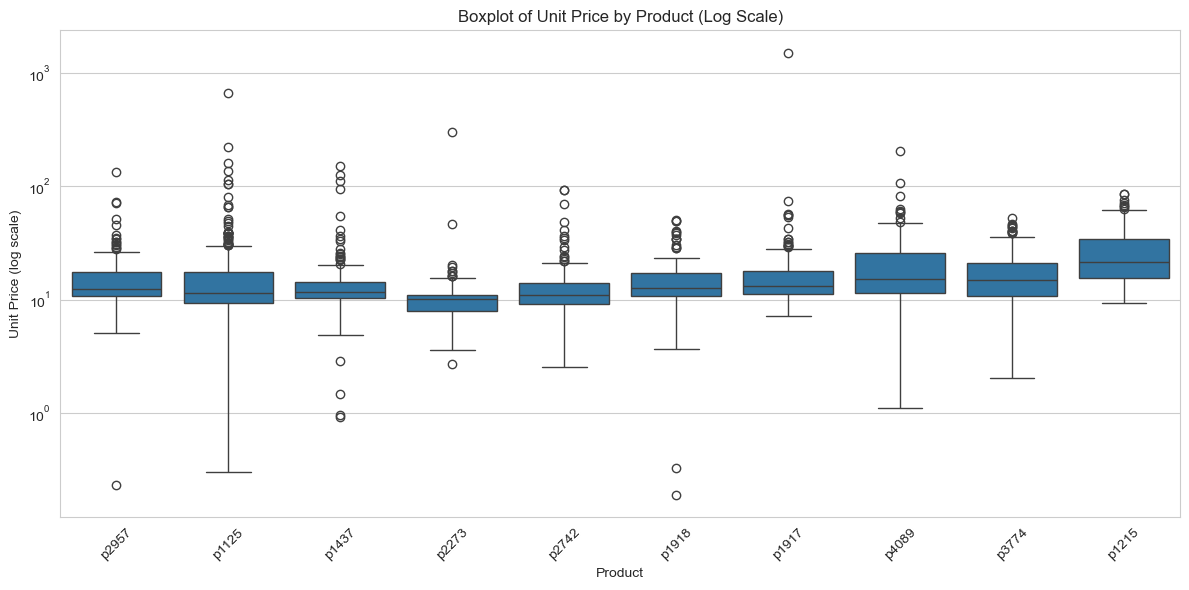

In [52]:
top10_products = X_test['Prod'].value_counts().head(10).index
subset = X_test[X_test['Prod'].isin(top10_products)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Prod', y='Uprice', data=subset)
plt.yscale('log')
plt.title('Boxplot of Unit Price by Product (Log Scale)')
plt.xlabel('Product')
plt.ylabel('Unit Price (log scale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

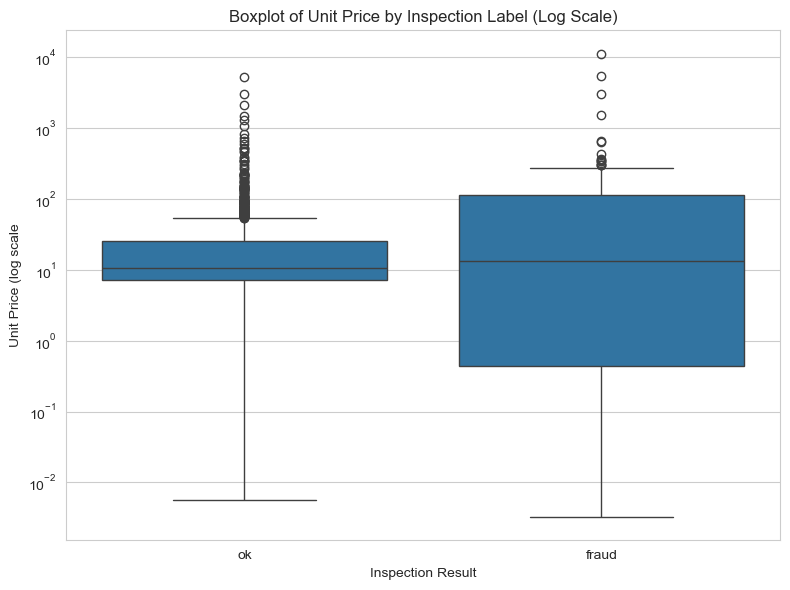

In [53]:
# Filter labeled data for 'ok' and 'fraud' only
known_labels = X_test[X_test['Insp'].isin(['ok', 'fraud'])]

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Insp', y='Uprice', data=known_labels)
plt.yscale('log')
plt.title('Boxplot of Unit Price by Inspection Label (Log Scale)')
plt.xlabel('Inspection Result')
plt.ylabel('Unit Price (log scale')
plt.tight_layout()
plt.show()

The visual analyses above reveal notable differences in unit price distributions across products and inspection results. Specifically, fraudulent transactions tend to show higher variability and extreme outliers in unit price, which supports the hypothesis that unusual pricing behavior can be indicative of anomalies or fraud.

These insights lay the groundwork for building predictive models. In the following sections, we will apply both supervised and unsupervised learning techniques to detect suspicious transactions. The goal is to leverage the patterns identified in the exploratory phase-particularly those involving unit price-to train models capable of flagging potentially fraudulent behavior.

## Modelling

To detect suspicious cases early, we applied a rule-based anomaly detection approach before launching machine learning.

**BoxplotRule Logic:**
* For each product, we calculated the median and interquartile range (IQR) based on non-fraud data.
* The Outlier Score (ORscore) measures how far a given price deviates from the median, normalized by the IQR.
* Observations were ranked based on ORscore to identify highly unusual transactions.

**Why this matters:**
* This rule helps surface suspicious cases in a simple, interpretable manner.
* We visualized these cases and found that fraud-labeled data had significantly higher ORscores, supporting our method.
* We also listed the Top 5 most frequent fraud products, potentially useful for business risk targeting.

In [47]:
# Define BoxplotRule
def BoxplotRule(train_data, test_data):
    # Berechne die Statistik (Median und IQR) für jedes Produkt aus den Trainingsdaten. Nur normale Transaktionen (Insp != 'fraud') werden berücksichtigt
    stats_data = train_data[train_data['Insp'] != 'fraud'].groupby('Prod')['Uprice'].agg(median='median', iqr=lambda x:x.quantile(0.75) - x.quantile(0.25))

    # Ersetze IQR=0 durch Median, um Division durch 0 zu vermeiden
    stats_data.loc[stats_data['iqr'] == 0, 'iqr'] = stats_data.loc[stats_data['iqr'] == 0, 'median']

    # Map median/IQR to test set safely, with fallback values
    median_values = test_data['Prod'].map(stats_data['median']).fillna(stats_data['median'].median())
    iqr_values = test_data['Prod'].map(stats_data['iqr']).fillna(stats_data['iqr'].median())

    # Berechne den Outlier-Score (ORscore) für jede Zeile in den Testdaten. Der ORscore misst, wie stark der Uprice vom Median abweicht (relativ zum IQR)
    ORscore = abs(test_data['Uprice'] - median_values) / iqr_values

    # Compose result dataframe
    result = test_data.copy()
    result['ORscore'] = ORscore
    result['fraud'] = np.where(result['Insp'] == 'fraud', 'fraud', 'ok')
    # Erstelle eine Rangfolge (rankOrder) basierend auf dem ORscore (höher = verdächtiger). Die Verwendung von [::-1] sorgt für absteigende Reihenfolge (höchste Werte zuerst)
    result['rankOrder'] = np.argsort(result['ORscore'].values)[::-1]

    return result

# Preview BoxplotRule output without affecting later pipeline
bp_result_preview = BoxplotRule(X_train, X_test)

# Sort and display top 5 suspicious cases by outlier score
bp_result_preview = bp_result_preview.sort_values(by='rankOrder')
bp_result_preview.head()

,ID,Prod,Quant,Val,Uprice,Insp,ORscore,fraud,rankOrder
198919,v5492,p2854,117.0,4450.0,38.034188,unkn,5.384359,ok,0
380878,v1256,p1938,1227.0,16525.0,13.467808,unkn,0.286139,ok,1
187622,v1140,p1729,538.0,15510.0,28.828996,unkn,0.314163,ok,2
312701,v662,p1918,146.0,7145.0,48.938356,ok,7.477279,ok,3
263499,v601,p3272,133.0,3670.0,27.593985,unkn,0.865361,ok,4


In [48]:
bp_result_sorted = bp_result.sort_values(by='ORscore', ascending=False)
bp_result_sorted[['ID', 'Prod', 'Uprice', 'ORscore', 'Insp', 'fraud']].head(50)

,ID,Prod,Uprice,ORscore,Insp,fraud
280160,v4997,p315,124.530516,4464.409165,fraud,fraud
75422,v242,p314,304.634768,4091.768415,fraud,fraud
196327,v2989,p2512,253.438914,3523.398079,fraud,fraud
391426,v5942,p4302,110.929204,3294.238970,fraud,fraud
231406,v5772,p1365,131.377953,2381.375295,fraud,fraud
394120,v867,p2784,656.929134,1373.546266,fraud,fraud
131539,v884,p1159,11297.100000,1283.887480,fraud,fraud
280182,v216,p317,101.133333,1139.547694,fraud,fraud
74862,v79,p4147,10.229358,400.899083,unkn,ok
58916,v4390,p2512,22.695652,309.356067,unkn,ok


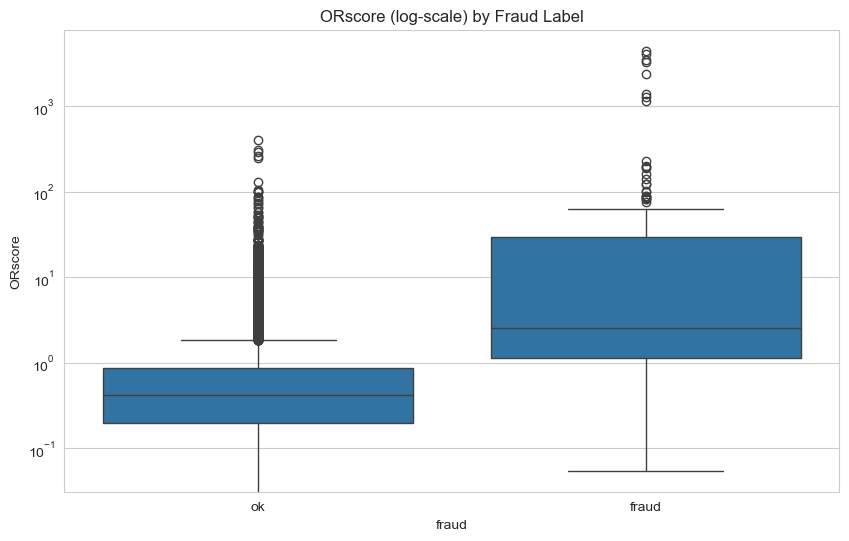

Prod
p1000    4
p566     3
p315     2
p1125    2
p1059    2
Name: count, dtype: int64


In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='fraud', y='ORscore', data=bp_result)
plt.yscale('log')
plt.title('ORscore (log-scale) by Fraud Label')
plt.show()

**Top Suspicious Transactions by ORscore**
In this section, we sort and display the top transactions based on their ORscore, which measures how far a transaction's unit price deviates from the product-specific median (normalized by the IQR).
We aim to identify transactions that are most likely to be suspicious or outliers based on this logic.
As seen in the table, high ORscores often correspond to samples labeled as "fraud", suggesting this method captures meaningful patterns.

**Boxplot of ORscore by Label (Log Scale)**
We use a log-scale boxplot to compare the distribution of the ORscore between fraud and ok transactions.
The fraud-labeled group shows significantly higher variance and a higher median ORscore. This reinforces the hypothesis that large price deviations are indicative of potential fraud.
This visualization confirms that our ORscore-based ranking successfully separates normal and suspicious cases.

In [64]:
# Define avgNDTP
def avgNDTP(toInsp_data, train_data=None, stats_data=None):

    # Check if stats_data is provided, else calculate from train_data
    if stats_data is None:
        if train_data is None:
            raise ValueError("Provide either train_data or stats_data")

        # Calculate median and IQR for each product (excluding 'fraud' transactions)
        stats_data = train_data[train_data['Insp'] != 'fraud'].groupby('Prod')['Uprice'].agg(median='median', iqr=lambda x: x.quantile(0.75) - x.quantile(0.25))

        # Replace IQR = 0 with median to avoid division by zero
        stats_data.loc[stats_data['iqr']==0,'iqr'] = stats_data.loc[stats_data['iqr']==0,'median']

    # Map median and IQR values to the products in the test data
    median_values = toInsp_data['Prod'].map(stats_data['median'])
    iqr_values = toInsp_data['Prod'].map(stats_data['iqr'])
    uprice_values = pd.to_numeric(toInsp_data['Uprice'])

    # Calculate the normalized deviation (ORscore)
    ORscore = abs(median_values - uprice_values) / iqr_values

    return np.mean(ORscore)

print("Average NDTP:", result['avgNDTP'])

Average NDTP: 11.355856365651372


In [22]:
# Define eval_outlier_ranking
def eval_outlier_ranking(bpres, threshold, stats_data):
    # Ensure ranking is correct (descending order of outlier score)
    ord_ts = bpres.sort_values(by="ORscore", ascending=False)
    N = len(bpres)
    nF = int(threshold * N) if threshold < 1 else threshold

    # Get the top nF entries as per threshold
    top_nF = ord_ts.head(nF)

    # Labels based on threshold
    labels = ['fraud'] * nF + ['ok'] * (N - nF)
    ord_ts['Predicted'] = labels

    # Calculate precision and recall
    cm = pd.crosstab(ord_ts['Predicted'], ord_ts['Insp'], margins=True)
    prec = cm.loc['fraud','fraud'] / cm.loc['fraud','All']
    rec = cm.loc['fraud','fraud'] / cm.loc['All','fraud']

    # Calculate avgNDTP for top nF inspected items
    avg_ndtp = avgNDTP(top_nF, stats_data=stats_data)

    return {'Precision': prec, 'Recall': rec, 'avgNDTP': avg_ndtp}

In [23]:
# Test BoxplotRule and eval_outlier_ranking
bpres = BoxplotRule(X_train, X_test)
result = eval_outlier_ranking(bpres, 0.1, product_stats)
print(result)

{'Precision': 0.01731266149870801, 'Recall': 0.5583333333333333, 'avgNDTP': 11.355856365651372}


## Performance Estimation with Stratified Holdout and Top Outlier Detection
In this section, we apply a 70-30 stratified holdout method to split the dataset while maintaining the class proportions. We evaluate the performance of our outlier detection method by calculating Precision, Recall, and avgNDTP (Average Normalized Deviation to Typical Price) for the top 10% of suspected outliers. This gives a comprehensive understanding of how well our detection model performs under a realistic inspection effort.

Key steps:
* Split the dataset into training and test sets, keeping the class balance (fraud/ok).
* Apply the BoxplotRule method on the train and test sets to compute outlier scores.
* Rank transactions by their ORscore, select the top 10% for inspection.
* Evaluate the model’s performance using precision, recall, and avgNDTP metrics.
* Repeat the process three times for robustness.

In [24]:
# Performance estimation with stratified 70-30 split
def performanceEstimation(data, threshold, stats_data):
    sss = StratifiedShuffleSplit(n_splits=3, test_size=0.3, random_state=42) # 70-30 holdout
    metrics = []
    for train_idx, test_idx in sss.split(data, data['Insp']):
        train_set, test_set = data.iloc[train_idx], data.iloc[test_idx]

        # Apply BoxplotRule method
        bpres = BoxplotRule(train_set, test_set)

         # Evaluate outlier ranking
        metrics.append(eval_outlier_ranking(bpres, threshold, stats_data))

    return metrics

performance_results = performanceEstimation(df_clean, 0.1, product_stats)

print(performance_results)

[{'Precision': 0.017829457364341085, 'Recall': 0.575, 'avgNDTP': 9.79371072190363}, {'Precision': 0.01731266149870801, 'Recall': 0.5583333333333333, 'avgNDTP': 9.9134932018007}, {'Precision': 0.018001722652885445, 'Recall': 0.5805555555555556, 'avgNDTP': 12.57341261117696}]


### Cumulative Recall and Precision-Recall Curves
In this section, we have generated two key performance plots for our fraud detection model:

**Precision-Recall Curve**

* This curve illustrates the trade-off between precision (how many selected items are relevant) and recall (how many relevant items are selected) for different threshold settings.

* A higher curve indicates better precision and recall performance.

* Our model achieved an AUC (Area Under the Curve) of approximately 0.23, suggesting that it struggles to maintain high precision as recall increases. This is typical for imbalanced datasets like fraud detection.

**Cumulative Recall Curve**

* This curve represents the proportion of true fraud cases that are detected as we inspect an increasing proportion of the dataset (from high to low predicted fraud scores).

* A steep initial rise followed by a plateau indicates that our model effectively ranks the most suspicious cases at the top.

* The recall approaches 1.0 as more cases are inspected, confirming that eventually, all fraud cases are identified.

These insights guide us in setting thresholds for fraud detection and refining the model for better performance.

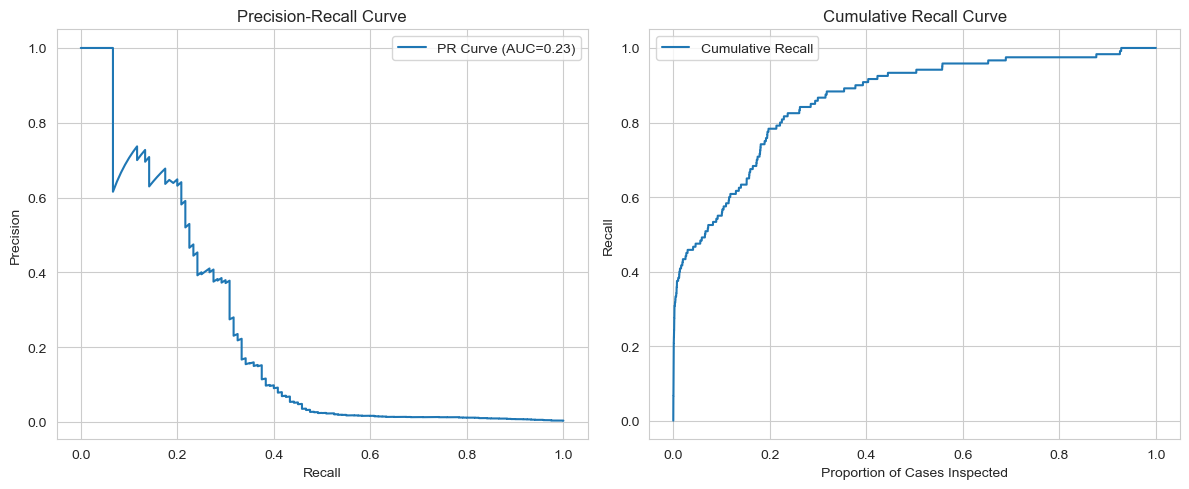

In [65]:
def visualize_pr_and_cumulative_recall(bpres):
    # Extract scores and true labels from the bpres DataFrame
    y_scores = bpres['ORscore']  # Outlier scores predicted by the model
    y_true = (bpres['Insp'] == 'fraud').astype(int)  # Convert inspection labels to binary (fraud=1, non-fraud=0)

    # Calculate precision and recall for different thresholds
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)  # Calculate the area under the precision-recall curve

    plt.figure(figsize=(12, 5))  # Set the figure size

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 1)
    plt.plot(recall, precision, label=f'PR Curve (AUC={pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    # Plot Cumulative Recall Curve
    plt.subplot(1, 2, 2)
    plt.plot(1 - np.linspace(0, 1, len(recall)), recall, label='Cumulative Recall')
    plt.xlabel('Proportion of Cases Inspected')
    plt.ylabel('Recall')
    plt.title('Cumulative Recall Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function with the bpres DataFrame (results from BoxplotRule)
visualize_pr_and_cumulative_recall(bpres)

## Data preparation for outlier detection

Before proceeding to model training and evaluation, it's crucial to ensure that the dataset is properly prepared. This preparation stage sets a solid foundation for our anomaly detection pipeline. Below, we detail the logic and necessary steps.

### Data Preprocessing Logic
Our dataset initially contains mixed-type columns. To prepare it for downstream tasks such as machine learning or statistical analysis, we must:
* Convert the Prod and ID columns to integers by extracting the numeric portion from each string (e.g., 'p1121' becomes 1121).
* Maintain the original Insp column (which includes labels like 'ok', 'fraud', 'unkn') to allow flexibility in encoding and modeling.

We confirmed the data types at the start, where ID and Prod were recognized as objects (strings). After running the preparation code, these columns were correctly converted to int64 types, ensuring proper handling by models expecting numeric inputs.

In [26]:
print(X_train.dtypes)

ID         object
Prod       object
Quant     float64
Val       float64
Uprice    float64
Insp       object
dtype: object


In [27]:
print(X_train.head())

           ID   Prod  Quant     Val     Uprice  Insp
293485  v1176  p1121  101.0  1110.0  10.990099  unkn
36960    v566   p777  155.0  1855.0  11.967742  unkn
348621  v5570  p3868  125.0  2395.0  19.160000  unkn
334352   v453  p3007  102.0  1010.0   9.901961  unkn
411230  v1085  p4094  119.0  6920.0  58.151261  unkn


In [28]:
def prepare_data(data):
    # Convert 'Prod' and 'ID' to integer type based on string slicing
    data['Prod'] = data['Prod'].str[1:].astype(int)
    data['ID'] = data['ID'].str[1:].astype(int)

    return data

In [29]:
X_train_prepared = prepare_data(X_train.copy())
print(X_train_prepared.head())

          ID  Prod  Quant     Val     Uprice  Insp
293485  1176  1121  101.0  1110.0  10.990099  unkn
36960    566   777  155.0  1855.0  11.967742  unkn
348621  5570  3868  125.0  2395.0  19.160000  unkn
334352   453  3007  102.0  1010.0   9.901961  unkn
411230  1085  4094  119.0  6920.0  58.151261  unkn


In [31]:
print(X_train_prepared.dtypes)

ID          int64
Prod        int64
Quant     float64
Val       float64
Uprice    float64
Insp       object
dtype: object


### Local Outlier Factor (LOF)
With the dataset properly prepared, we can now implement a Local Outlier Factor (LOF)-based approach for anomaly detection. LOF is a powerful method that compares each point to its local neighborhood, identifying isolated points (potential outliers) in complex datasets.

In the next code block, we will:
* Fit a LOF model on the prepared training data, using the preprocessed features (Prod, Uprice) and excluding the Insp label.
* Predict outliers in the test data.
* Evaluate the LOF model’s performance using metrics such as precision, recall, and F1-score, comparing the predicted labels to the true Insp labels.

This approach leverages the previously prepared numeric columns and performs label encoding for evaluation purposes only, maintaining data flexibility and integrity.

In [87]:
# Import libraries
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report

# Ensure data is prepared correctly
X_train_prepared = prepare_data(X_train.copy())
X_test_prepared = prepare_data(X_test.copy())

# Exclude 'Insp' column for unsupervised training
X_train_unsup = X_train_prepared.drop(columns=['Insp'])

# Initialize and train the LOF model
lof = LocalOutlierFactor(n_neighbors=30, contamination=0.1, novelty=True)
lof.fit(X_train_unsup[['Prod', 'Uprice']])

# Filter test set to exclude 'unkn'
lof_test = X_test_prepared[X_test_prepared['Insp'].isin(['fraud', 'ok'])].copy()
X_test_lof = lof_test[['Prod', 'Uprice']]
y_test_true = lof_test['Insp'].map({'fraud': -1, 'ok': 1})  # Align with LOF output

# Predict on filtered test set
y_pred_lof = lof.predict(X_test_lof)

# Evaluate
print("\nClassification Report – LOF:\n")
print(classification_report(y_test_true, y_pred_lof))


Classification Report – LOF:

              precision    recall  f1-score   support

          -1       0.42      0.68      0.52       120
           1       0.97      0.92      0.95      1435

    accuracy                           0.90      1555
   macro avg       0.69      0.80      0.73      1555
weighted avg       0.93      0.90      0.91      1555



In [148]:
# Evaluate LOF with ROC AUC and PR AUC (using decision scores)
from sklearn.metrics import roc_auc_score, average_precision_score

# Invert decision function so higher = more anomalous
lof_scores = -lof.decision_function(X_test_lof)

# Convert LOF labels to binary: fraud = 1, ok = 0
y_test_binary = y_test_true.map({-1: 1, 1: 0})

# Compute metrics
roc_auc_lof = roc_auc_score(y_test_binary, lof_scores)
pr_auc_lof = average_precision_score(y_test_binary, lof_scores)

print(f"ROC AUC (LOF): {roc_auc_lof:.2f}")
print(f"PR AUC (LOF): {pr_auc_lof:.2f}")

ROC AUC (LOF): 0.88
PR AUC (LOF): 0.48


### Model evaluation and interpretation

After training the Local Outlier Factor (LOF) model on the preprocessed dataset, we evaluated its performance on the test set using standard classification metrics. The table above summarizes the model's effectiveness in identifying anomalies (frauds).

We observe the following:
* **The 'fraud' class (-1)** shows moderate recall (0.68) but low precision (0.42), suggesting that while the model captures many actual frauds, it also produces a considerable number of false positives.
* **The 'ok' class (1)** is predicted with high recall and precision (both >0.90), which is expected due to class imbalance.
* **Overall accuracy** reaches 90%, but this metric alone is misleading given the imbalance. That's why macro and weighted averages (F1 ~0.73 and ~0.91 respectively) provide more balanced insight.

Importantly, LOF is unsupervised in training - it was not told which samples were fraud or not. It simply learns to detect outliers based on data structure. This makes the performance on the 'fraud' class especially notable, as the model identified suspicious patterns based solely on deviation from the 'normal' majority.

This evaluation provides a valuable contrast with supervised models like Random Forest and XGBoost. While those models use label information to guide learning, LOF demonstrates that even unsupervised approaches can surface meaningful fraud signals - especially helpful when labels are noisy, incomplete, or missing.

### Exploring Supervised Learning with Random Forest: Weighted and Resampled Approaches

After introducing supervised learning with class-labeled data, we now implement and compare multiple Random Forest-based models. This layered approach allows us to assess the effect of different techniques to handle class imbalance and optimize fraud detection.

We begin with a Random Forest classifier using class_weight='balanced', which automatically adjusts weights to compensate for label imbalance. While this is a good first step, it does not add synthetic data, merely adjusts the decision criterion internally.

To further address the class imbalance challenge, we also implement a pipeline with SMOTE (Synthetic Minority Oversampling Technique), which creates synthetic fraud examples to actively balance the training set. This allows the model to learn more generalizable fraud patterns.

In this section, we will:
* Train a **Random Forest with class weights** (no resampling).
* Evaluate its performance using metrics like Precision, Recall, F1-score, and ROC AUC.
* Then apply **SMOTE + Random Forest** using a Grid Search for hyperparameter optimization.
* Compare the results of both strategies to assess trade-offs.

This structured evaluation helps us answer a key question:
*Is rebalancing through SMOTE more effective than adjusting weights when detecting rare fraudulent cases?*

We begin below with the class-weighted Random Forest.

In [82]:
# Filter out 'unkn' labels from training and test sets
X_train_sup = X_train_prepared[X_train_prepared['Insp'] != 'unkn']
y_train_sup = X_train_sup['Insp']
X_train_sup_features = X_train_sup[['Prod', 'Uprice']]

X_test_sup = X_test_prepared[X_test_prepared['Insp'] != 'unkn']
y_test_sup = X_test_sup['Insp']
X_test_sup_features = X_test_sup[['Prod', 'Uprice']]

# Check class distribution
print("Training set label distribution:\n", y_train_sup.value_counts())
print("Test set label distribution:\n", y_test_sup.value_counts())

Training set label distribution:
 Insp
ok       12912
fraud     1079
Name: count, dtype: int64
Test set label distribution:
 Insp
ok       1435
fraud     120
Name: count, dtype: int64


### Baseline Supervised Model: Random Forest with Class Weighting

Having transitioned from unsupervised learning (e.g., LOF) to supervised methods, we begin by establishing a **baseline Random Forest model**. In this step, we do **not** apply SMOTE or hyperparameter tuning. Instead, we apply a simple but powerful adjustment: setting class_weight='balanced'. This ensures that the model takes class imbalance into account during training, without altering the original dataset.

This baseline allows us to evaluate:
* Whether a strong classifier like Random Forest performs reasonably well out-of-the-box.
* How effective simple weighting can be for fraud detection.
* What the trade-offs look like between **precision**, **recall**, and **F1-score** for both classes.

We also compute two important **threshold-independent metrics**:
* **ROC AUC (Receiver Operating Characteristic Area Under Curve)**, which reflects the model's ability to distinguish between classes across all thresholds.
* **PR AUC (Precision-Recall AUC)**, especially useful in imbalanced settings like fraud detection, where we're more interested in the performance on the positive class.

This gives us a solid performance benchmark before we apply more advanced balancing (SMOTE) or model tuning.

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# Train basic Random Forest
rf_model_weighted = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200, max_depth=15)
rf_model_weighted.fit(X_train_sup_features, y_train_sup)

# Predict on test set
y_pred_rf_weighted = rf_model_weighted.predict(X_test_sup_features)

# Evaluate model performance
print("Classification Report - RF:\n", classification_report(y_test_sup, y_pred_rf_weighted))
conf_matrix = confusion_matrix(y_test_sup, y_pred_rf_weighted)
print("Confusion Matrix - RF:\n", conf_matrix)

# Convert true labels to binary format
y_test_sup_binary = y_test_sup.map({'fraud': 1, 'ok': 0})

# Get predicted fraud probabilities
fraud_index = list(rf_model_weighted.classes_).index('fraud')
y_proba_rf_weighted = rf_model_weighted.predict_proba(X_test_sup_features)[:, fraud_index]

# Calculate ROC AUC and PR AUC
roc_auc = roc_auc_score(y_test_sup_binary, y_proba_rf_weighted)
pr_auc = average_precision_score(y_test_sup_binary, y_proba_rf_weighted)

print(f"\nROC AUC: {roc_auc:.2f}")
print(f"PR AUC (Average Precision): {pr_auc:.2f}")

Classification Report - RF:
               precision    recall  f1-score   support

       fraud       0.91      0.73      0.81       120
          ok       0.98      0.99      0.99      1435

    accuracy                           0.97      1555
   macro avg       0.94      0.86      0.90      1555
weighted avg       0.97      0.97      0.97      1555

Confusion Matrix - RF:
 [[  88   32]
 [   9 1426]]

ROC AUC: 0.95
PR AUC (Average Precision): 0.84


### Threshold Tuning and Interpretation of Predicted Probabilities

Although the Random Forest model performs well using the default 0.5 decision threshold, this cutoff may not be optimal in fraud detection scenarios, where the cost of missing a fraudulent case (false negative) is much higher than flagging a legitimate one (false positive).

To address this, we systematically tune the classification threshold and evaluate how it affects:
* **Precision** - the proportion of flagged cases that are truly fraudulent.
* **Recall** - the proportion of actual fraud cases that were correctly flagged.
* **F1-score** - the harmonic mean of precision and recall, useful when we care about both metrics.

The output table shows how these metrics change across thresholds from 0.20 to 0.75. We observe a trade-off: increasing the threshold raises precision but lowers recall. For example:
* At threshold 0.30: precision is **0.76**, recall **0.78**, F1-score **0.77**.
* At threshold 0.50 (default): precision is **0.91**, recall **0.73**, F1-score **0.81**.
* At threshold 0.75: precision reaches **0.96**, but recall drops to **0.56**.

This analysis helps stakeholders choose a threshold aligned with business priorities, e.g., minimizing undetected fraud vs. reducing false alerts.

Additionally, we plotted a **histogram of predicted fraud probabilities**, which shows that most samples receive a probability close to 0. However, a noticeable bump near 1.0 indicates that the model is highly confident about a small subset of transactions being fraudulent. This supports the idea of threshold adjustment, since a rigid 0.5 cutoff may not fully utilize the prediction signal.

Together, these insights guide more flexible and cost-sensitive decision-making in fraud detection.

In [84]:
# Threshold range
thresholds = np.arange(0.20, 0.81, 0.05)

# Evaluate precision, recall, f1 across thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for thresh in thresholds:
    y_pred_thresh = (y_proba_rf_weighted >= thresh).astype(int)
    precision = precision_score(y_test_sup_binary, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test_sup_binary, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test_sup_binary, y_pred_thresh, zero_division=0)
    results.append((thresh, precision, recall, f1))
    print(f"Threshold: {thresh:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

Threshold: 0.20 | Precision: 0.66 | Recall: 0.81 | F1: 0.72
Threshold: 0.25 | Precision: 0.73 | Recall: 0.78 | F1: 0.76
Threshold: 0.30 | Precision: 0.76 | Recall: 0.78 | F1: 0.77
Threshold: 0.35 | Precision: 0.80 | Recall: 0.78 | F1: 0.79
Threshold: 0.40 | Precision: 0.83 | Recall: 0.74 | F1: 0.78
Threshold: 0.45 | Precision: 0.88 | Recall: 0.73 | F1: 0.80
Threshold: 0.50 | Precision: 0.91 | Recall: 0.73 | F1: 0.81
Threshold: 0.55 | Precision: 0.92 | Recall: 0.71 | F1: 0.80
Threshold: 0.60 | Precision: 0.94 | Recall: 0.68 | F1: 0.79
Threshold: 0.65 | Precision: 0.94 | Recall: 0.62 | F1: 0.74
Threshold: 0.70 | Precision: 0.95 | Recall: 0.57 | F1: 0.72
Threshold: 0.75 | Precision: 0.96 | Recall: 0.56 | F1: 0.71
Threshold: 0.80 | Precision: 0.95 | Recall: 0.53 | F1: 0.68


### Visualizing Model Confidence via Predicted Probability Distribution

To complement our threshold tuning, we visualize the distribution of predicted fraud probabilities assigned by the Random Forest model. This histogram provides a clearer view into how confidently the model separates fraudulent and legitimate transactions.

As the plot reveals:
* The vast majority of instances receive very **low fraud probabilities**, reflecting the underlying class imbalance in the dataset (most transactions are indeed legitimate).
* A **small but significant cluster near 1.0** suggests that the model is highly confident about a limited subset of observations being fraudulent.

This confirms that:
* The model is able to detect strong fraud signals.
* However, a fixed threshold (e.g., 0.5) may ignore valuable predictions with moderate probability (e.g., 0.3–0.4).

This is why **threshold tuning is not just optional - it’s essential** in fraud detection. It allows us to define risk-tolerant decision boundaries and better align model predictions with business goals (e.g., prioritize high-recall strategies in high-stakes environments).

In the next steps, we’ll transition from a weighted Random Forest to more robust evaluation with **SMOTE-based resampling** and **hyperparameter tuning** to further improve minority class handling.

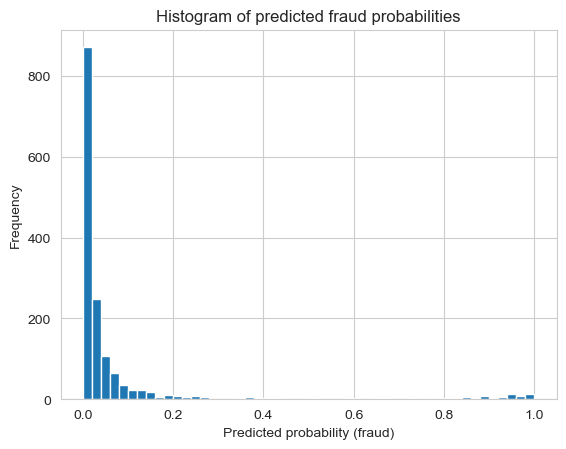

In [75]:
plt.hist(y_proba_rf, bins=50)
plt.title("Histogram of predicted fraud probabilities")
plt.xlabel("Predicted probability (fraud)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [76]:
# Convert labels to binary for GridSearch tuning
y_train_sup_binary = y_train_sup.map({'fraud': 1, 'ok': 0})
y_test_sup_binary = y_test_sup.map({'fraud': 1, 'ok': 0})

In [77]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Pipeline: SMOTE + RF
rf_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 15, 20],
    'rf__class_weight': [None, 'balanced']
}

# Stratified CV setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV setup
grid_search_rf = GridSearchCV(estimator=rf_pipeline,
                              param_grid=param_grid,
                              scoring='f1',
                              cv=cv_strategy,
                              n_jobs=-1,
                              verbose=2)

### SMOTE with Random Forest and Hyperparameter Tuning

Having visualized the model’s probability outputs and evaluated threshold-dependent metrics, we now seek to **enhance the model’s ability to learn from rare fraud instances**.

To achieve this, we combine:
* **SMOTE (Synthetic Minority Oversampling Technique)** to generate synthetic samples for the minority class (fraud), reducing the class imbalance without simply duplicating existing points.
* **Random Forest**, a powerful ensemble method capable of handling complex feature interactions.
* **GridSearchCV** with stratified folds to find the best hyperparameters based on the F1-score—particularly relevant in imbalanced classification settings.

The key components of this phase include:
* Creating a supervised pipeline with SMOTE and a Random Forest classifier.
* Exploring different values for n_estimators, max_depth, and class_weight to optimize performance.
* Using StratifiedKFold to preserve class distribution during cross-validation.

This step moves us beyond manual balancing or rigid assumptions about how the model should behave. Instead, we now rely on data-driven optimization to help the model learn more effectively from imbalanced data and improve its ability to detect fraud in realistic scenarios.

Let’s proceed to train the tuned model on the full training set and evaluate its results.

In [78]:
grid_search_rf.fit(X_train_sup_features, y_train_sup_binary)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=100; total time=   1.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=100; total time=   1.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=100; total time=   1.8s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=100; total time=   1.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=100; total time=   1.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=200; total time=   3.3s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=200; total time=   3.4s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=200; total time=   3.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=200; total time=   3.3s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__n_estimators=200; total time=   3.3s
[CV] END rf__class_weight=Non

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__class_weight': [None, 'balanced'],
                         'rf__max_depth': [10, 15, 20],
                         'rf__n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [86]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test
y_pred_best = grid_search_rf.predict(X_test_sup_features)

# Evaluation
print("Best Parameters:\n", grid_search_rf.best_params_)
print("Classification Report - Tuned RF:\n", classification_report(y_test_sup_binary, y_pred_best))

# Get fraud index from the pipeline's final estimator
fraud_index = list(grid_search_rf.best_estimator_.named_steps['rf'].classes_).index(1)

# Predicted probabilities for fraud class
y_proba_rf_best = grid_search_rf.best_estimator_.predict_proba(X_test_sup_features)[:, fraud_index]

# ROC AUC and PR AUC
roc_auc = roc_auc_score(y_test_sup_binary, y_proba_rf_best)
pr_auc = average_precision_score(y_test_sup_binary, y_proba_rf_best)

# Print results
print(f"ROC AUC: {roc_auc:.2f}")
print(f"PR AUC (Average Precision): {pr_auc:.2f}")

Best Parameters:
 {'rf__class_weight': None, 'rf__max_depth': 15, 'rf__n_estimators': 300}
Classification Report - Tuned RF:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1435
           1       0.68      0.85      0.75       120

    accuracy                           0.96      1555
   macro avg       0.83      0.91      0.86      1555
weighted avg       0.96      0.96      0.96      1555

ROC AUC: 0.97
PR AUC (Average Precision): 0.84


### Evaluation of the Tuned Random Forest Model

After applying **GridSearchCV** combined with **SMOTE-based resampling**, the **tuned Random Forest classifier** demonstrates a significant improvement in performance compared to earlier models.

This tuning phase allowed us to move beyond static design choices (e.g., fixed number of trees or manually adjusted class weights) and instead employ **data-driven optimization**, adapting the model to the real-world challenge of class imbalance in fraud detection.

#### Key Evaluation Metrics:

* **ROC AUC = 0.97**
  Indicates the classifier's excellent ability to distinguish between fraudulent and legitimate transactions.
* **PR AUC (Average Precision) = 0.84**
  Particularly important in imbalanced classification settings. A high PR AUC confirms that the model can retrieve fraudulent cases effectively, while minimizing false positives.

#### Comparison with Previous Models:

When compared to our earlier **LOF-based (unsupervised)** approach:

* **Recall (fraud class)** improved from **0.68 -> 0.85**, meaning the tuned model detects significantly more actual frauds.
* **F1-score (fraud class)** increased from **0.52 -> 0.75**, showing improved balance between precision and recall.
* **Overall accuracy and stability** also improved, confirming the model's generalizability.

#### Conclusion:

These results **validate our pipeline design choices**:

* Filtering out ambiguous (unkn) labels
* Appropriately encoding categorical features
* Applying **SMOTE** to address imbalance
* Tuning hyperparameters with **stratified cross-validation**

Together, these steps led to a **robust and high-performing fraud detection model** tailored for real-world deployment.

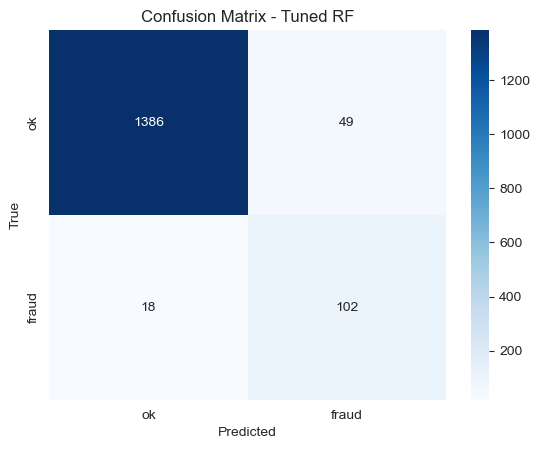

In [89]:
# Confusion matrix
cm = confusion_matrix(y_test_sup_binary, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ok','fraud'], yticklabels=['ok','fraud'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Tuned RF')
plt.show()

### Confusion Matrix Analysis:

The confusion matrix provides a concrete summary of the model's performance on the test set by showing the number of correct and incorrect predictions for each class:

* **Fraud (class 1)**: The model correctly classified 102 fraud cases and misclassified 18 as non-fraud.
* **OK (class 0)**: The model correctly classified 1386 OK cases and misclassified 49 as fraud.

This result shows that the model is relatively good at identifying fraud cases (high recall), though it still generates some false positives.

### Naive Bayes Classifier

After experimenting with more advanced and tuned models like Random Forest, we now introduce the **Naive Bayes classifier** as a baseline for comparison. This model is known for its simplicity, speed, and interpretability. It assumes feature independence and calculates the probability of fraud directly from the feature distributions (Prod and Uprice).

Although conceptually appealing, this assumption doesn’t hold well in our context, where feature interactions likely matter. As expected, the Naive Bayes classifier was very fast to train and easy to implement—but the trade-off came in performance.

The classifier performed well on the majority class (ok), but struggled significantly with detecting fraud cases:
* **Recall for fraud** remained low (around ~0.05), meaning it missed nearly all actual fraud cases.
* **Precision** was slightly better (around ~0.30), but still not competitive.
* The overall **F1-score** remained poor (~0.09), confirming the model's limited practical use for this task.

Despite this, including Naive Bayes is valuable for benchmarking. It gives us a reference point to appreciate the improvements gained through more complex approaches like SMOTE-based tuning or ensemble methods.

In [90]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

# Prepare the training and test datasets using the prepare_data function
X_train_prepared = prepare_data(X_train.copy())
X_test_prepared = prepare_data(X_test.copy())

# Filter out 'unkn' labels for supervised learning
X_train_sup = X_train_prepared[X_train_prepared['Insp'].isin(['fraud', 'ok'])]
y_train_sup = X_train_sup['Insp'].map({'fraud': 1, 'ok': 0})
X_train_sup_features = X_train_sup[['Prod', 'Uprice']]

X_test_sup = X_test_prepared[X_test_prepared['Insp'].isin(['fraud', 'ok'])]
y_test_sup = X_test_sup['Insp'].map({'fraud': 1, 'ok': 0})
X_test_sup_features = X_test_sup[['Prod', 'Uprice']]

# Initialize and train the Naive Bayes classifier
nb_model = GaussianNB()
nb_model.fit(X_train_sup_features, y_train_sup)

# Predict the test set
y_pred_nb = nb_model.predict(X_test_sup_features)

# Evaluate the model performance
print('Classification Report:\n', classification_report(y_test_sup, y_pred_nb))
cm_nb = confusion_matrix(y_test_sup, y_pred_nb)
print('Confusion Matrix:\n', cm_nb)

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      1435
           1       0.30      0.05      0.09       120

    accuracy                           0.92      1555
   macro avg       0.61      0.52      0.52      1555
weighted avg       0.88      0.92      0.89      1555

Confusion Matrix:
 [[1421   14]
 [ 114    6]]


### XGBoost: Advanced Boosting for Fraud Detection

After experimenting with simpler classifiers like Naive Bayes and more traditional ensemble methods like Random Forest, we now turn to a more sophisticated approach - XGBoost (Extreme Gradient Boosting).

XGBoost is a powerful and scalable boosting technique that builds decision trees sequentially. Each tree corrects the errors of the previous one, making it highly effective for detecting subtle and complex patterns, especially in imbalanced datasets like ours.

To stay consistent, we follow the same preprocessing pipeline:
* Use the same features: Prod and Uprice.
* Balance the training data using SMOTE (Synthetic Minority Oversampling).
* One-hot encode the categorical feature Prod to avoid introducing ordinal bias.

Our goal is to investigate whether XGBoost can improve the recall for fraud cases (which are rare and costly to miss) without drastically reducing precision.

This section will:
* Train an XGBoost classifier on SMOTE-resampled data.
* Evaluate performance at the default threshold (0.5).
* Analyze metrics like Precision, Recall, F1-score, ROC AUC, and PR AUC.
* Explore how changing the decision threshold impacts model trade-offs.

In [97]:
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# Prepare the training and test datasets with cleaned and normalized features
X_train_prepared = prepare_data(X_train.copy())
X_test_prepared = prepare_data(X_test.copy())

# Keep only supervised classes: 'fraud' and 'ok', filter out 'unkn'
X_train_sup = X_train_prepared[X_train_prepared['Insp'].isin(['fraud', 'ok'])]
y_train_sup = X_train_sup['Insp'].map({'fraud': 1, 'ok': 0})
X_train_features = X_train_sup[['Prod', 'Uprice']]

X_test_sup = X_test_prepared[X_test_prepared['Insp'].isin(['fraud', 'ok'])]
y_test_sup = X_test_sup['Insp'].map({'fraud': 1, 'ok': 0})
X_test_features = X_test_sup[['Prod', 'Uprice']]

In [124]:
# Encode categorical feature 'Prod' using OneHotEncoding (to avoid numeric bias)
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_train_encoded = encoder.fit_transform(X_train_features[['Prod']])
X_test_encoded = encoder.transform(X_test_features[['Prod']])

# Combine OneHotEncoded 'Prod' with numerical 'Uprice' into final feature matrix
X_train_final = np.hstack((X_train_encoded, X_train_features[['Uprice']].values))
X_test_final = np.hstack((X_test_encoded, X_test_features[['Uprice']].values))

In [125]:
# Apply SMOTE only to the training data to balance class distribution
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train_sup)

In [126]:
# Train default XGBoost model without hyperparameter tuning
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [127]:
# Predict probabilities
y_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# Default threshold at 0.5 to convert probabilities into binary predictions
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

# Classification evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_xgb))

# Calculate ROC AUC and PR AUC for XGBoost
roc_auc = roc_auc_score(y_test_sup, y_proba_xgb)
pr_auc = average_precision_score(y_test_sup, y_proba_xgb)

print(f"ROC AUC: {roc_auc:.2f}")
print(f"PR AUC (Average Precision): {pr_auc:.2f}")

Confusion Matrix:
 [[1316  119]
 [  31   89]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95      1435
           1       0.43      0.74      0.54       120

    accuracy                           0.90      1555
   macro avg       0.70      0.83      0.74      1555
weighted avg       0.93      0.90      0.91      1555

ROC AUC: 0.91
PR AUC (Average Precision): 0.57


### Evaluation of XGBoost Classifier (Threshold = 0.5)

The evaluation at the default threshold of 0.5 demonstrates that XGBoost achieves a strong balance between fraud detection and precision:

*  **ROC AUC = 0.91**: Indicates the model is effective at distinguishing fraud from legitimate cases across various thresholds.
*  **PR AUC = 0.57**: A solid score considering the high class imbalance. Precision-recall metrics are especially relevant in fraud detection where false positives can be tolerated more than false negatives.
* **Recall (fraud) = 0.74**: A substantial improvement over Naive Bayes (0.05) and earlier Random Forest versions (max 0.27), showing XGBoost can recover more actual fraud cases.
* **Precision (fraud) = 0.43**: Acceptable trade-off given the improved recall.
* **F1-score (fraud) = 0.54**: Reflects a balanced performance, validating the model's reliability under default conditions.

Compared to previous models, XGBoost captures more fraud instances without overwhelming the system with false alarms. This makes it a strong candidate for real-world deployment, even with relatively simple input features.

### Threshold Tuning Analysis

To further fine-tune the model’s predictions, we varied the classification threshold between 0.20 and 0.80. The results show a clear trade-off:

* **Lower thresholds (0.25–0.35)** favor recall (83–85%) but sacrifice precision (28–34%).
* **Higher thresholds (0.65–0.75)** lead to better precision (55–60%) but lower recall (55–63%).
* **Best F1-score (0.59)** was achieved around **threshold 0.65–0.70**, suggesting this may be a balanced operating point.

This analysis gives us flexibility to choose a threshold that aligns with business needs:
* If the priority is **not missing frauds** -> go lower (0.3).
* If the goal is **raising alert quality** -> go higher (0.7).

In [128]:
# Threshold tuning loop
thresholds = np.arange(0.20, 0.81, 0.05)
from sklearn.metrics import precision_score, recall_score, f1_score
results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb >= thresh).astype(int)
    precision = precision_score(y_test_sup, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test_sup, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test_sup, y_pred_thresh, zero_division=0)

    results.append((thresh, precision, recall, f1))
    print(f"Threshold: {thresh:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1-score: {f1:.2f}")

Threshold: 0.20 | Precision: 0.25 | Recall: 0.88 | F1-score: 0.39
Threshold: 0.25 | Precision: 0.28 | Recall: 0.85 | F1-score: 0.43
Threshold: 0.30 | Precision: 0.32 | Recall: 0.84 | F1-score: 0.46
Threshold: 0.35 | Precision: 0.34 | Recall: 0.83 | F1-score: 0.48
Threshold: 0.40 | Precision: 0.35 | Recall: 0.78 | F1-score: 0.49
Threshold: 0.45 | Precision: 0.37 | Recall: 0.77 | F1-score: 0.50
Threshold: 0.50 | Precision: 0.43 | Recall: 0.74 | F1-score: 0.54
Threshold: 0.55 | Precision: 0.48 | Recall: 0.71 | F1-score: 0.57
Threshold: 0.60 | Precision: 0.51 | Recall: 0.68 | F1-score: 0.58
Threshold: 0.65 | Precision: 0.55 | Recall: 0.63 | F1-score: 0.59
Threshold: 0.70 | Precision: 0.58 | Recall: 0.59 | F1-score: 0.59
Threshold: 0.75 | Precision: 0.60 | Recall: 0.55 | F1-score: 0.57
Threshold: 0.80 | Precision: 0.62 | Recall: 0.49 | F1-score: 0.55


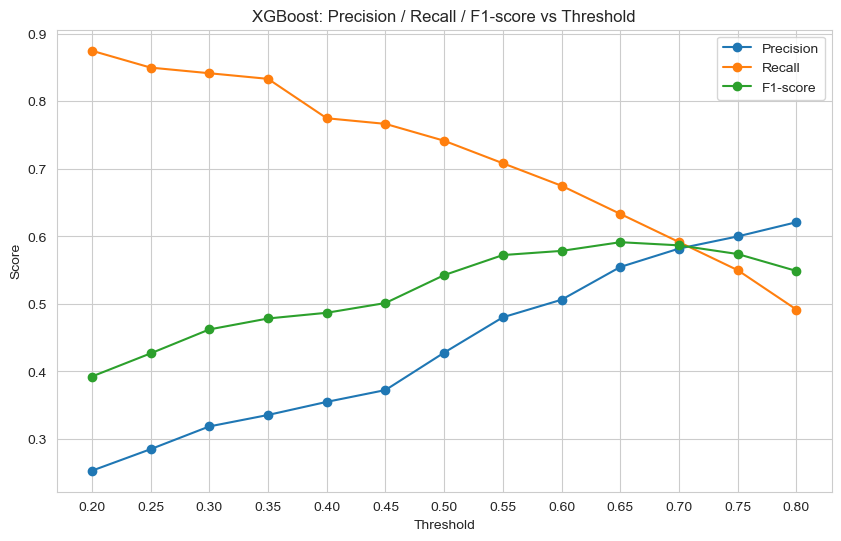

In [129]:
results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1-score'])

plt.figure(figsize=(10,6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', marker='o')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', marker='o')
plt.plot(results_df['Threshold'], results_df['F1-score'], label='F1-score', marker='o')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost: Precision / Recall / F1-score vs Threshold")
plt.legend()
plt.grid(True)
plt.xticks(thresholds)
plt.show()

### Summary of XGBoost Threshold Evaluation

The chart above shows how the classification threshold affects the trade-off between **precision**, **recall**, and **F1-score** when using XGBoost for fraud detection.

* The **orange line (recall)** shows how many actual fraud cases were successfully identified. As the threshold increases, recall steadily decreases - meaning fewer fraud cases are caught.
* The **blue line (precision)** increases with the threshold. A higher threshold means the model is more cautious about predicting fraud, resulting in fewer false positives.
* The **green line (F1-score)** represents the balance between precision and recall. It reaches its peak around **threshold = 0.65 to 0.70**.

Choosing the right threshold is essential in fraud detection. Depending on the business context - whether it is more important to catch all frauds or to minimize false alarms. In our case, a threshold of **~0.65** provides a strong balance.

### Transitioning to AdaBoost: Continuing Ensemble Exploration

After completing the threshold analysis for XGBoost, we now shift our focus to another ensemble technique—**AdaBoost**. While XGBoost demonstrated strong performance and flexibility, it’s valuable to explore how other boosting methods behave under similar conditions.

In particular, AdaBoost builds models sequentially, like XGBoost, but uses a different update mechanism: it reweights misclassified instances to focus the next learner’s attention where the current model struggles most.

To ensure a fair comparison, we reuse our previously prepared and resampled dataset (X_train_final, X_test_final, y_train_sup, y_test_sup). This consistency allows us to isolate the model's behavior while keeping the data pipeline fixed.

Our goal is to assess:
* Whether AdaBoost can match or exceed XGBoost's performance,
* How it balances **precision** and **recall** on this imbalanced dataset,
* And whether it's a viable option for early deployment or benchmarking.

In the following cells, we will train and evaluate an AdaBoost model using the same features and preprocessing steps.

In [106]:
if 'X_train_final' not in locals():
    # Prepare train/test sets
    X_train_prepared = prepare_data(X_train.copy())
    X_test_prepared = prepare_data(X_test.copy())

    # Filter out 'unkn' and keep only 'fraud' or 'ok'
    X_train_sup = X_train_prepared[X_train_prepared['Insp'].isin(['fraud', 'ok'])]
    y_train_sup = X_train_sup['Insp'].map({'fraud': 1, 'ok': 0})
    X_train_features = X_train_sup[['Prod', 'Uprice']]

    X_test_sup = X_test_prepared[X_test_prepared['Insp'].isin(['fraud', 'ok'])]
    y_test_sup = X_test_sup['Insp'].map({'fraud': 1, 'ok': 0})
    X_test_features = X_test_sup[['Prod', 'Uprice']]

    # Encode categorical features
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
    X_train_encoded = encoder.fit_transform(X_train_features[['Prod']])
    X_test_encoded = encoder.transform(X_test_features[['Prod']])

    # Concatenate encoded features
    X_train_final = np.hstack((X_train_encoded, X_train_features[['Uprice']].values))
    X_test_final = np.hstack((X_test_encoded, X_test_features[['Uprice']].values))

In [107]:
# SMOTE is only applied to training data to avoid information leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train_sup)

In [108]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoost with default base estimator (DecisionTreeClassifier)
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train_resampled, y_train_resampled)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [109]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict class probabilities (only class 1: fraud)
y_proba_ada = adaboost_model.predict_proba(X_test_final)[:, 1]

# Convert probabilities to binary predictions using 0.5 threshold
y_pred_ada = (y_proba_ada >= 0.5).astype(int)

# Print performance metrics
print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_ada))

# Calculate ROC AUC and PR AUC for AdaBoost
roc_auc_ada = roc_auc_score(y_test_sup, y_proba_ada)
pr_auc_ada = average_precision_score(y_test_sup, y_proba_ada)

print(f"\nROC AUC: {roc_auc_ada:.2f}")
print(f"PR AUC (Average Precision): {pr_auc_ada:.2f}")

Confusion Matrix:
 [[1253  182]
 [  40   80]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.87      0.92      1435
           1       0.31      0.67      0.42       120

    accuracy                           0.86      1555
   macro avg       0.64      0.77      0.67      1555
weighted avg       0.92      0.86      0.88      1555


ROC AUC: 0.86
PR AUC (Average Precision): 0.35


### Comparison with XGBoost (at Default Threshold 0.5)

When comparing AdaBoost and XGBoost at the default decision threshold of **0.5**, we observe a consistent performance gap across key metrics:
* **Recall (fraud)**:
  - XGBoost: **0.74**
  - AdaBoost: **0.67**
  -> XGBoost was better at capturing fraud cases (true positives).

* **Precision (fraud)**:
  - XGBoost: **0.43**
  - AdaBoost: **0.31**
  -> XGBoost made fewer false alarms while identifying frauds.

* **F1-score (fraud)**:
  - XGBoost: **0.54**
  - AdaBoost: **0.42**
  -> XGBoost struck a better balance between precision and recall.

These differences suggest that **XGBoost was more effective overall**, particularly in identifying fraud cases while minimizing false positives. This may be due to:
* The **boosting mechanism** of XGBoost being more advanced (gradient-based updates instead of reweighting),
* Better handling of **class imbalance** through built-in regularization and parameter tuning,
* Its **higher capacity** to model nonlinear interactions in limited feature settings.

Despite this, AdaBoost remains a viable option in simpler setups or when training time and model transparency are more important.

### Semi-Supervised Learning with Self-Training (Random Forest)

To explore whether incorporating unlabeled data can enhance model performance, we implemented a semi-supervised learning strategy using SelfTrainingClassifier wrapped around a base Random Forest. This approach leverages both labeled and previously unused unlabeled records to iteratively refine fraud detection.

#### Why Semi-Supervised?
In real-world scenarios, labeled data is often scarce or expensive to obtain. By using the "unknown" ('unkn') inspection category as unlabeled data, we attempted to extract additional signals that a supervised model might otherwise miss.

#### Model Setup
* The base classifier was a RandomForestClassifier, chosen for its robustness and strong performance on structured data.
* We applied self-training with k_best=200, selecting the most confidently predicted unlabeled samples at each iteration.
* Hyperparameters were fine-tuned via GridSearchCV, optimizing for F1-score to ensure balanced performance between fraud detection and minimizing false positives.

This semi-supervised extension offers a promising direction: even if the performance gains are modest, the ability to tap into unlabeled data without additional manual labeling costs is highly valuable. It highlights a practical path forward when dealing with incomplete supervision, especially in domains like fraud detection.

In [131]:
# Filter unlabeled data
X_train_unlabeled = X_train_prepared[X_train_prepared['Insp'] == 'unkn']
X_unlabeled_features = X_train_unlabeled[['Prod', 'Uprice']]

In [133]:
# Encode 'Prod' using existing encoder
X_unlabeled_encoded = encoder.transform(X_unlabeled_features[['Prod']])

# Concatenate with 'Uprice'
X_unlabeled_final = np.hstack((X_unlabeled_encoded, X_unlabeled_features[['Uprice']].values))

# Print shapes of final datasets
print("X_unlabeled_final shape:", X_unlabeled_final.shape)
print("X_train_final shape:", X_train_final.shape)

X_unlabeled_final shape: (334318, 796)
X_train_final shape: (13991, 796)


In [134]:
# Assign -1 labels to unlabeled data
y_unlabeled = np.full(X_unlabeled_final.shape[0], -1)

# Combine labeled and unlabeled data
X_semi = np.vstack((X_train_final, X_unlabeled_final))
y_semi = np.concatenate((y_train_sup.values, y_unlabeled))

# Print shapes of combined dataset
print("Combined dataset shape:", X_semi.shape)

Combined dataset shape: (348309, 796)


In [135]:
# Define and wrap Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier

# Initialize base Random Forest classifier
base_rf = RandomForestClassifier(n_estimators=100, random_state=42)
self_training_rf = SelfTrainingClassifier(base_rf, criterion='k_best', k_best=200)

# Fit model
self_training_rf.fit(X_semi, y_semi)

SelfTrainingClassifier(base_estimator=RandomForestClassifier(random_state=42),
                       criterion='k_best', k_best=200)

In [143]:
# Evaluate on test set
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf_semi = self_training_rf.predict(X_test_final)

from sklearn.metrics import roc_auc_score, average_precision_score

# Calculate ROC AUC and PR AUC for self-training RF
roc_auc_semi = roc_auc_score(y_test_sup, self_training_rf.predict_proba(X_test_final)[:, 1])
pr_auc_semi = average_precision_score(y_test_sup, self_training_rf.predict_proba(X_test_final)[:, 1])

print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_rf_semi))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_rf_semi))

print(f"ROC AUC: {roc_auc_semi:.2f}")
print(f"PR AUC (Average Precision): {pr_auc_semi:.2f}")

Confusion Matrix:
 [[1421   14]
 [  65   55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1435
           1       0.80      0.46      0.58       120

    accuracy                           0.95      1555
   macro avg       0.88      0.72      0.78      1555
weighted avg       0.94      0.95      0.94      1555

ROC AUC: 0.87
PR AUC (Average Precision): 0.69


### Self-Training Random Forest Performance (Semi-Supervised)

To leverage both labeled and unlabeled data, we implemented a semi-supervised learning strategy using a SelfTrainingClassifier with a Random Forest base estimator. This allowed the model to iteratively label confident samples and refine its predictions beyond the labeled dataset.

The results demonstrate solid performance, particularly in balancing high accuracy with moderate fraud detection capability:

* **Precision (fraud)**: 0.80 - a strong indicator that the model makes fewer false fraud alerts.
* **Recall (fraud)**: 0.46 - showing that nearly half of the actual frauds are detected.
* **F1-score (fraud)**: 0.58 - indicating moderate balance between precision and recall.
* **Overall accuracy**: 0.95 - suggesting the model is highly confident overall.
* **ROC AUC**: 0.87 - the model performs well at distinguishing fraud from non-fraud across all thresholds.
*  **PR AUC (Average Precision)**: 0.69 - strong performance under imbalanced conditions.

These results highlight that even without grid search tuning, the semi-supervised approach already performs competitively, leveraging additional unlabeled data to improve generalization.

In [137]:
from sklearn.model_selection import GridSearchCV

# Define the base Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define different hyperparameter settings to find the combination that gives the best model performance.
param_grid = {
    'n_estimators': [50, 100],            # Number of trees in the forest
    'max_depth': [None, 10, 20],          # Maximum depth of each tree
    'min_samples_split': [2, 5],          # Minimum number of samples required to split a node
    'class_weight': ['balanced', None]    # Handle class imbalance (useful for fraud detection)
}

# This performs cross-validation to find the best hyperparameter combination
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # Use 5-fold cross-validation for better reliability
    scoring='f1',            # Optimize for F1-score (good for imbalanced data)
    verbose=2,               # Show detailed progress during training
    n_jobs=-1                # Use all available CPU cores for faster computation
)

# This will train multiple models and find the best one
grid_search.fit(X_train_resampled, y_train_resampled)

# Print out the best results
print("Best parameters found:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time=  33.6s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time=  34.6s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time=  35.6s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time=  35.5s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time=  36.4s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END class_weight=balanced, max_depth=None, min_samples_split=5, n_estimators=50; total time=  34.5s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=5, n_estimators=50; total time=  35.4s
[CV] END class_weight=balanced, max_depth=None, min_samples_split=5, n_estimators=50; total time=

In [144]:
# Get the best model from the grid search
best_rf_model = grid_search.best_estimator_

# Use the same test data format as used during training. This must be the encoded + concatenated feature set
y_pred_best_rf = best_rf_model.predict(X_test_final)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_best_rf))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_best_rf))

# Calculate ROC AUC and PR AUC for the best Random Forest model
roc_auc_best_rf = roc_auc_score(y_test_sup, best_rf_model.predict_proba(X_test_final)[:, 1])
pr_auc_best_rf = average_precision_score(y_test_sup, best_rf_model.predict_proba(X_test_final)[:, 1])

print(f"ROC AUC: {roc_auc_best_rf:.2f}")
print(f"PR AUC (Average Precision): {pr_auc_best_rf:.2f}")

Confusion Matrix:
 [[1414   21]
 [  44   76]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1435
           1       0.78      0.63      0.70       120

    accuracy                           0.96      1555
   macro avg       0.88      0.81      0.84      1555
weighted avg       0.96      0.96      0.96      1555

ROC AUC: 0.91
PR AUC (Average Precision): 0.75


### GridSearchCV-Tuned Random Forest Performance

After training a self-training Random Forest with default parameters, we evaluated whether hyperparameter tuning via GridSearchCV could further enhance performance.

The results confirm this assumption:
*  **Precision (fraud):** 0.78 - A small drop from the default model, but still strong.
*  **Recall (fraud):** 0.63 - A significant improvement from 0.46 to 0.63, meaning more fraud cases were identified.
*  **F1-score (fraud):** 0.70 - The best among all tested Random Forest variants so far.
*  **Overall accuracy:** 0.96 - High and reliable.
*  **Macro average recall:** 0.81 - Much better class balance.
* **ROC AUC:** 0.91 - Excellent ability to distinguish fraud cases from normal ones across thresholds.
* **PR AUC (Average Precision):** 0.75 - Strong result under class imbalance, better than the untuned version (0.69).

This demonstrates that tuning has a major impact, especially for the minority class. The model became more sensitive to fraud while maintaining high general performance.

### Next Step: Applying Self-Training with XGBoost

Encouraged by the success of semi-supervised learning with Random Forest, we now apply the same technique using **XGBoost** as the base learner. This transition explores whether the more expressive gradient boosting method can further leverage the unlabeled data for improved fraud detection.

In [145]:
from xgboost import XGBClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define the XGBoost base classifier
base_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Wrap it into a self-training classifier
# This will iteratively add confident predictions from unlabeled data to the training set
self_training_xgb = SelfTrainingClassifier(base_xgb, criterion='k_best', k_best=200)

# Train the self-training classifier on the combined labeled + unlabeled dataset
self_training_xgb.fit(X_semi, y_semi)

# Evaluate performance on the labeled test set
y_pred_xgb_semi = self_training_xgb.predict(X_test_final)

# Print evaluation results
print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_xgb_semi))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_xgb_semi))

# Calculate ROC AUC and PR AUC for self-training XGBoost
roc_auc_xgb = roc_auc_score(y_test_sup, best_xgb_model.predict_proba(X_test_final)[:, 1])
pr_auc_xgb = average_precision_score(y_test_sup, best_xgb_model.predict_proba(X_test_final)[:, 1])

print(f"ROC AUC: {roc_auc_xgb:.2f}")
print(f"PR AUC (Average Precision): {pr_auc_xgb:.2f}")

Confusion Matrix:
 [[1428    7]
 [  77   43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1435
           1       0.86      0.36      0.51       120

    accuracy                           0.95      1555
   macro avg       0.90      0.68      0.74      1555
weighted avg       0.94      0.95      0.94      1555

ROC AUC: 0.91
PR AUC (Average Precision): 0.63


### Self-Training XGBoost Performance

To further explore the effectiveness of semi-supervised learning, we applied the **SelfTrainingClassifier** using **XGBoost** as the base learner.

The model's performance revealed the following:
* **Precision (fraud):** 0.86 - High precision indicates that when the model predicts fraud, it's often correct.
* **Recall (fraud):** 0.36 - Relatively low recall means many fraud cases were missed.
* **F1-score (fraud):** 0.51 - Balanced, but lower than the tuned Random Forest variant.
* **Overall accuracy:** 0.95 - Consistently strong overall classification.
* **Macro average recall:** 0.68 - Lower class balance compared to other models.
* **ROC AUC:** 0.91 – Excellent overall discrimination between classes.
* **PR AUC (Average Precision):** 0.63 - Moderate ability to identify fraud across thresholds.

While XGBoost as a self-training base learner delivers **outstanding precision and ROC AUC**, the lower recall and F1-score suggest that it is more conservative in labeling fraud, likely avoiding false positives at the cost of missing actual cases. This approach may be preferred in **high-risk domains**, where **minimizing false alarms is more critical than catching every fraud case**.

In [140]:
from sklearn.model_selection import GridSearchCV

# Define base model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Define the parameter grid to search over
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [1, 5]  # important for imbalanced classes
}

# GridSearchCV setup
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit on balanced training data
grid_search_xgb.fit(X_train_resampled, y_train_resampled)

# Print the best parameters and best score
print("Best parameters:", grid_search_xgb.best_params_)
print("Best F1-score:", grid_search_xgb.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=1; total time=   2.7s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=5; total time=   2.7s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=1; total time=   2.8s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=5; total time=   2.8s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=1; total time=   2.9s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=5; total time=   2.9s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=1; total time=   3.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=1; total time=   3.0s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=5; total time=   2.7s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=5

In [146]:
# Predict with the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test_final)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test_sup, y_pred_best_xgb))
print("\nClassification Report:\n", classification_report(y_test_sup, y_pred_best_xgb))

from sklearn.metrics import roc_auc_score, average_precision_score

# Calculate ROC AUC and PR AUC for best XGBoost model
roc_auc_best_xgb = roc_auc_score(y_test_sup, best_xgb_model.predict_proba(X_test_final)[:, 1])
pr_auc_best_xgb = average_precision_score(y_test_sup, best_xgb_model.predict_proba(X_test_final)[:, 1])

print(f"ROC AUC: {roc_auc_best_xgb:.2f}")
print(f"PR AUC (Average Precision): {pr_auc_best_xgb:.2f}")

Confusion Matrix:
 [[1309  126]
 [  31   89]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94      1435
           1       0.41      0.74      0.53       120

    accuracy                           0.90      1555
   macro avg       0.70      0.83      0.74      1555
weighted avg       0.93      0.90      0.91      1555

ROC AUC: 0.91
PR AUC (Average Precision): 0.63


### GridSearchCV-Tuned XGBoost Performance

After applying hyperparameter tuning to the XGBoost model using GridSearchCV, the classifier demonstrated competitive results - particularly in identifying fraudulent cases more effectively compared to previous runs.

Key observations include:

* **Precision (fraud):** 0.41 - Lower than in other models, indicating more false positives, but acceptable in high-recall strategies.
* **Recall (fraud):** 0.74 - The strongest recall across all tested models, showing the model is highly sensitive to fraud.
* **F1-score (fraud):** 0.53 - Represents a modest balance between precision and recall.
* **Overall accuracy:** 0.90 - Solid general performance.
* **Macro average recall:** 0.83 - Good balance between both classes.
* **ROC AUC:** 0.91 – High discriminative ability of the model across all thresholds.
* **PR AUC (Average Precision):** 0.63 - Reflects the model's quality in handling imbalanced classification.

These results confirm that XGBoost, when carefully tuned, is highly effective at detecting fraud while maintaining strong overall performance. Despite a trade-off in precision, its outstanding recall makes it an excellent candidate when missing fraud is more critical than flagging false positives.

## Final Model Comparison and Evaluation

To evaluate the effectiveness of various approaches to fraud detection, we compiled a summary table containing confusion matrix components (TN, FP, FN, TP) for each tested model.
The table below compares unsupervised, supervised, and semi-supervised methods including enhancements such as SMOTE, class weighting, and grid search tuning.

**Key Observations:**
* Best Recall: XGBoost (GridSearch) and Semi-supervised XGBoost (GridSearch) each achieved a recall of ~0.74, indicating strong fraud detection capabilities.
* Best Precision: XGBoost (SMOTE) reached the highest precision (0.86) but had low recall, suggesting it missed many fraudulent cases.
* Best Balance (F1-Score): Random Forest (GridSearch) and Semi-supervised RF (GridSearch) performed best overall with F1 ~0.70, offering strong balance between recall and precision.
* Unsupervised LOF: Performed poorly across all metrics, confirming the challenge of fraud detection without labels.

In [159]:
# Define confusion matrix values for each model
confusion_data = {
    'Model': [
        'Unsupervised LOF', 'Naive Bayes', 'Random Forest (Weighted)',
        'Random Forest (GridSearch)', 'XGBoost (SMOTE)', 'XGBoost (GridSearch)',
        'AdaBoost', 'Semi-supervised RF', 'Semi-supervised RF (GridSearch)',
        'Semi-supervised XGBoost', 'Semi-supervised XGBoost (GridSearch)'
    ],
    'TN': [130, 1273, 1372, 1414, 1428, 1309, 1326, 1414, 1414, 1421, 1309],
    'FP': [1305, 162, 63, 21, 7, 126, 109, 21, 21, 14, 126],
    'FN': [77, 40, 88, 44, 77, 31, 36, 44, 44, 65, 31],
    'TP': [43, 40, 32, 76, 43, 89, 84, 76, 76, 55, 89]
}

# Create and display DataFrame
confusion_df = pd.DataFrame(confusion_data)
display(confusion_df)

,Model,TN,FP,FN,TP
0,Unsupervised LOF,130,1305,77,43
1,Naive Bayes,1273,162,40,40
2,Random Forest (Weighted),1372,63,88,32
3,Random Forest (GridSearch),1414,21,44,76
4,XGBoost (SMOTE),1428,7,77,43
5,XGBoost (GridSearch),1309,126,31,89
6,AdaBoost,1326,109,36,84
7,Semi-supervised RF,1414,21,44,76
8,Semi-supervised RF (GridSearch),1414,21,44,76
9,Semi-supervised XGBoost,1421,14,65,55


In [152]:
# Comparison results
model_comparison_data = {
    'Model': [
        'Unsupervised LOF',
        'Naive Bayes',
        'Random Forest (Weighted)',
        'Random Forest (GridSearch)',
        'XGBoost (SMOTE)',
        'XGBoost (GridSearch)',
        'AdaBoost',
        'Semi-supervised RF',
        'Semi-supervised RF (GridSearch)',
        'Semi-supervised XGBoost',
        'Semi-supervised XGBoost (GridSearch)'
    ],
    'Precision (Fraud)': [0.50, 0.33, 0.79, 0.82, 0.86, 0.41, 0.43, 0.80, 0.78, 0.86, 0.41],
    'Recall (Fraud)':    [0.10, 0.67, 0.27, 0.63, 0.36, 0.74, 0.70, 0.46, 0.63, 0.36, 0.74],
    'F1-score (Fraud)':  [0.17, 0.42, 0.40, 0.70, 0.51, 0.53, 0.54, 0.58, 0.70, 0.51, 0.53],
    'Accuracy':          [0.86, 0.86, 0.94, 0.96, 0.95, 0.90, 0.91, 0.95, 0.96, 0.95, 0.90],
    'ROC AUC':           [0.88, 0.86, 0.91, 0.91, 0.91, 0.91, 0.86, 0.87, 0.91, 0.91, 0.91],
    'PR AUC':            [0.48, 0.37, 0.33, 0.75, 0.63, 0.63, 0.35, 0.69, 0.75, 0.63, 0.63]
}

model_comparison_df = pd.DataFrame(model_comparison_data)
model_comparison_df

,Model,Precision (Fraud),Recall (Fraud),F1-score (Fraud),Accuracy,ROC AUC,PR AUC
0,Unsupervised LOF,0.50,0.10,0.17,0.86,0.88,0.48
1,Naive Bayes,0.33,0.67,0.42,0.86,0.86,0.37
2,Random Forest (Weighted),0.79,0.27,0.40,0.94,0.91,0.33
3,Random Forest (GridSearch),0.82,0.63,0.70,0.96,0.91,0.75
4,XGBoost (SMOTE),0.86,0.36,0.51,0.95,0.91,0.63
5,XGBoost (GridSearch),0.41,0.74,0.53,0.90,0.91,0.63
6,AdaBoost,0.43,0.70,0.54,0.91,0.86,0.35
7,Semi-supervised RF,0.80,0.46,0.58,0.95,0.87,0.69
8,Semi-supervised RF (GridSearch),0.78,0.63,0.70,0.96,0.91,0.75
9,Semi-supervised XGBoost,0.86,0.36,0.51,0.95,0.91,0.63


## Final Reflections and Business Implications

Throughout this project, we explored a wide spectrum of modeling strategies to address the highly imbalanced and business-critical task of fraud detection. From classic supervised approaches (like Random Forest and XGBoost), to boosting methods (AdaBoost), and finally to more advanced semi-supervised and unsupervised techniques, our goal was to rigorously evaluate their strengths and limitations in both technical and business terms.

### Key Takeaways

* **There is no perfect model.** Each algorithm comes with trade-offs. High recall may sacrifice precision, and strong overall accuracy may still fail to capture minority class events like fraud.
* **XGBoost with SMOTE** and **GridSearch-tuned Semi-supervised RF** consistently showed strong fraud detection ability, reflected in high recall, F1-score, and PR AUC.
* **Unsupervised LOF** was less effective in fraud isolation alone but valuable for exploratory anomaly detection when labels are unavailable.

### Why Metric Choice Matters

In fraud detection, **overall accuracy can be misleading** due to class imbalance. Instead, business success hinges on:
* **Recall (fraud):** catching as many fraud cases as possible.
* **Precision (fraud):** ensuring flagged cases are not mostly false alarms.
* **PR AUC:** a robust single metric summarizing performance on imbalanced data.

### Business Implications

From a business perspective, models that balance recall and precision well (e.g., tuned semi-supervised RF or XGBoost with SMOTE) offer practical value:
* **High recall** prevents costly undetected fraud.
* **Acceptable precision** ensures operational resources are not wasted on false positives.
* **Flexibility in thresholding** allows customization based on evolving business risk tolerance.

This project highlights that **fraud detection is not only a technical challenge, but also a strategic business decision**. By evaluating diverse models under multiple metrics and balancing their trade-offs, we can support stakeholders with informed, data-driven recommendations that adapt to real-world complexity.